In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats, special
from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from essential_functions import pearson_correlation_analysis, spearman_correlation_analysis

/Users/danmayonde/Desktop/ML_Master_Project/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The output directory of all the files saved in this notebook

output_path = "../correlations"

In [3]:
# Load the big dataset containing every features to a Pandas DataFrame

df = pd.read_csv("../Data/BData.csv")


# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop("Aspect (˚)", axis=1, inplace=True)

df.head(10)

,Sample_ID,Longitude,Latitude,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Land Use,Dist_Main_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,S1,16.654245,-23.791474,4.54993,-0.371390,0.928477,1554,0.0655,barren,2473,...,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,S2,16.654298,-23.791963,4.22451,0.800000,-0.600000,1557,0.0684,barren,2507,...,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,S3,16.654220,-23.792418,6.00415,0.633238,-0.773957,1555,0.0672,barren,2529,...,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,S4,16.654164,-23.792956,6.09267,0.832050,-0.554700,1551,0.0590,barren,2559,...,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,S5,16.653748,-23.792745,3.04634,0.554700,-0.832050,1554,0.0593,barren,2511,...,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338
5,S6,16.653734,-23.792229,1.33591,-0.316228,-0.948683,1556,0.0615,barren,2476,...,89.0,9.4,1.6,8.0,179.0,89.5,3.39,132.867,22.824,6.566
6,S7,16.653816,-23.791701,4.54993,-0.371390,0.928477,1555,0.0594,barren,2450,...,87.1,11.4,1.5,7.5,486.0,242.5,1.97,121.958,26.613,5.643
7,S8,16.653762,-23.791077,0.84490,0.894427,0.447214,1552,0.0658,barren,2407,...,88.6,9.8,1.6,7.2,591.0,295.0,2.80,58.462,19.708,7.113
8,S9,16.653527,-23.790519,4.22451,0.800000,-0.600000,1555,0.0664,barren,2354,...,89.4,8.6,2.0,8.1,246.0,122.5,3.42,125.126,29.015,6.654
9,S10,16.653313,-23.790021,3.48362,-0.242536,0.970142,1554,0.0657,barren,2307,...,86.9,11.2,1.9,7.5,140.0,70.5,2.47,99.254,17.899,4.950


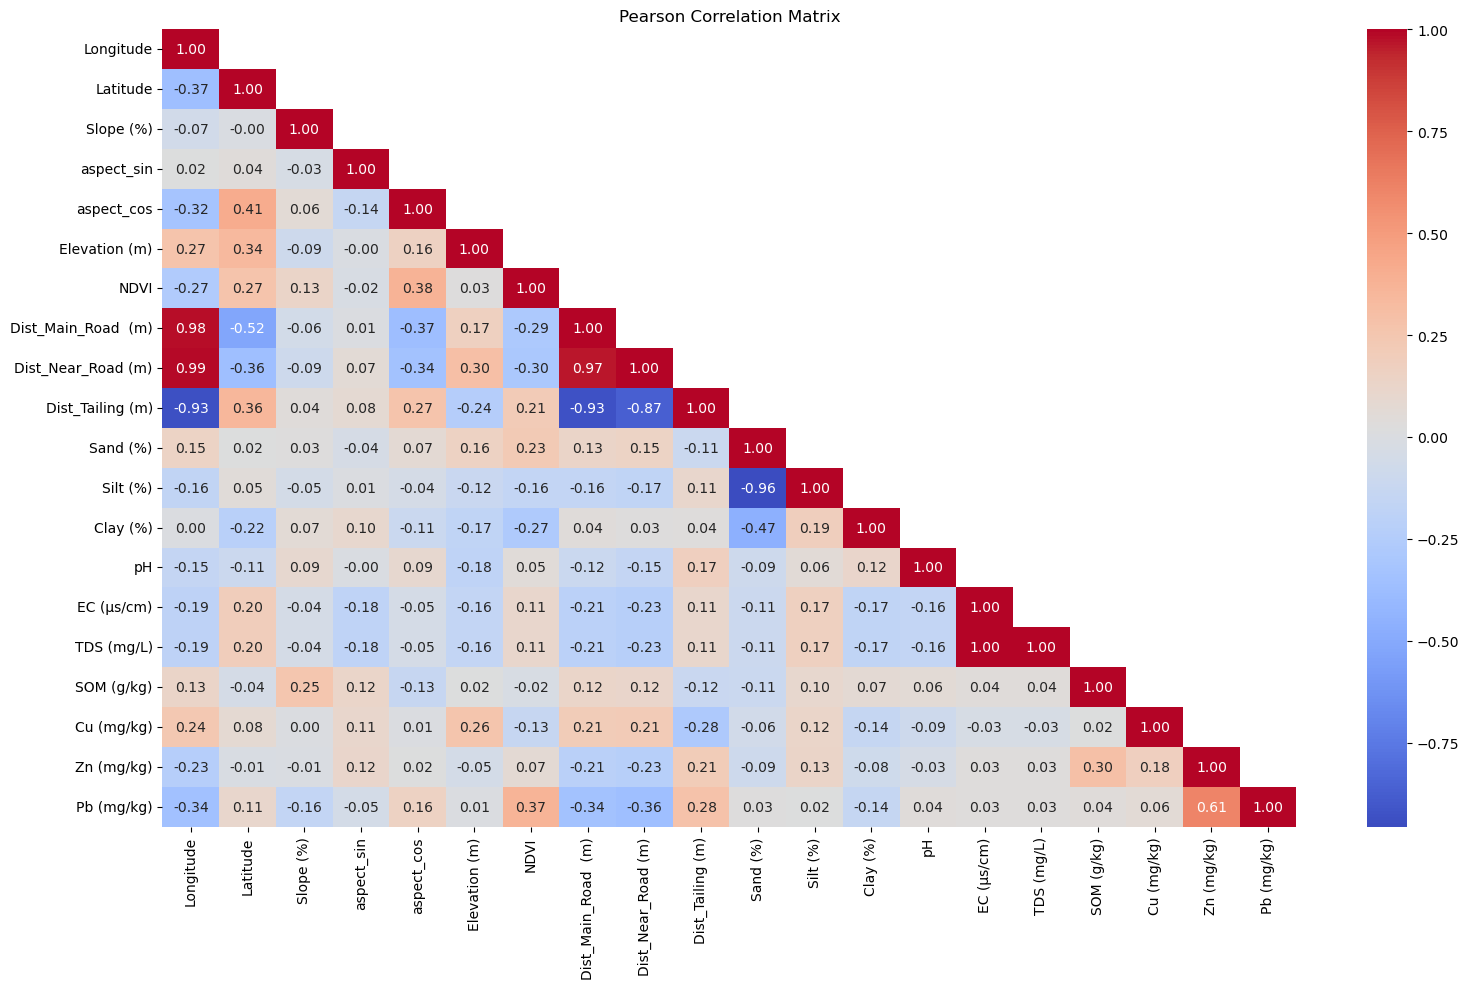

,Longitude,Latitude,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Dist_Main_Road (m),Dist_Near_Road (m),Dist_Tailing (m),Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
Longitude,1.000000,-0.366918,-0.067349,0.018874,-0.322871,0.267620,-0.267645,0.984636,0.986416,-0.934108,0.148919,-0.164507,0.001892,-0.151994,-0.188178,-0.188224,0.129891,0.239711,-0.230762,-0.344709
Latitude,-0.366918,1.000000,-0.002624,0.044353,0.414170,0.339879,0.273876,-0.522006,-0.363927,0.358056,0.017186,0.051257,-0.216571,-0.106962,0.196184,0.196243,-0.041774,0.077665,-0.014567,0.111169
Slope (%),-0.067349,-0.002624,1.000000,-0.027528,0.060870,-0.091855,0.130636,-0.056630,-0.091586,0.039305,0.025033,-0.049427,0.066614,0.094328,-0.042537,-0.042491,0.252938,0.004355,-0.005442,-0.156821
aspect_sin,0.018874,0.044353,-0.027528,1.000000,-0.141131,-0.002102,-0.018740,0.006802,0.065198,0.081383,-0.035744,0.005355,0.099929,-0.004672,-0.178998,-0.179009,0.124312,0.110166,0.119351,-0.046766
aspect_cos,-0.322871,0.414170,0.060870,-0.141131,1.000000,0.159668,0.379631,-0.369134,-0.343993,0.273638,0.070028,-0.040766,-0.113731,0.092917,-0.045285,-0.045248,-0.134417,0.005194,0.020973,0.156399
Elevation (m),0.267620,0.339879,-0.091855,-0.002102,0.159668,1.000000,0.028078,0.169230,0.297233,-0.244041,0.155951,-0.115790,-0.169627,-0.182982,-0.156771,-0.156786,0.018530,0.261287,-0.053297,0.006417
NDVI,-0.267645,0.273876,0.130636,-0.018740,0.379631,0.028078,1.000000,-0.291093,-0.296879,0.214857,0.225887,-0.161155,-0.270108,0.049638,0.107850,0.107939,-0.021644,-0.134754,0.073460,0.367354
Dist_Main_Road (m),0.984636,-0.522006,-0.056630,0.006802,-0.369134,0.169230,-0.291093,1.000000,0.969375,-0.926131,0.133231,-0.159098,0.038461,-0.115098,-0.205509,-0.205562,0.124893,0.206369,-0.212135,-0.340575
Dist_Near_Road (m),0.986416,-0.363927,-0.091586,0.065198,-0.343993,0.297233,-0.296879,0.969375,1.000000,-0.870002,0.149158,-0.173596,0.029168,-0.146475,-0.225700,-0.225748,0.120244,0.213405,-0.227856,-0.362723
Dist_Tailing (m),-0.934108,0.358056,0.039305,0.081383,0.273638,-0.244041,0.214857,-0.926131,-0.870002,1.000000,-0.112674,0.112329,0.035348,0.174996,0.110424,0.110475,-0.117795,-0.282590,0.211726,0.275576


In [4]:
# drop categorical data for pearson analysis
continuous_df = df.select_dtypes(include=[np.number]).copy()

corr_matrix = pearson_correlation_analysis(df,
                                           output_filename="pearson_corr.csv",
                                           save=True,
                                           plot_filename="PCorr_matrix.png",
                                           plot=True)

corr_matrix

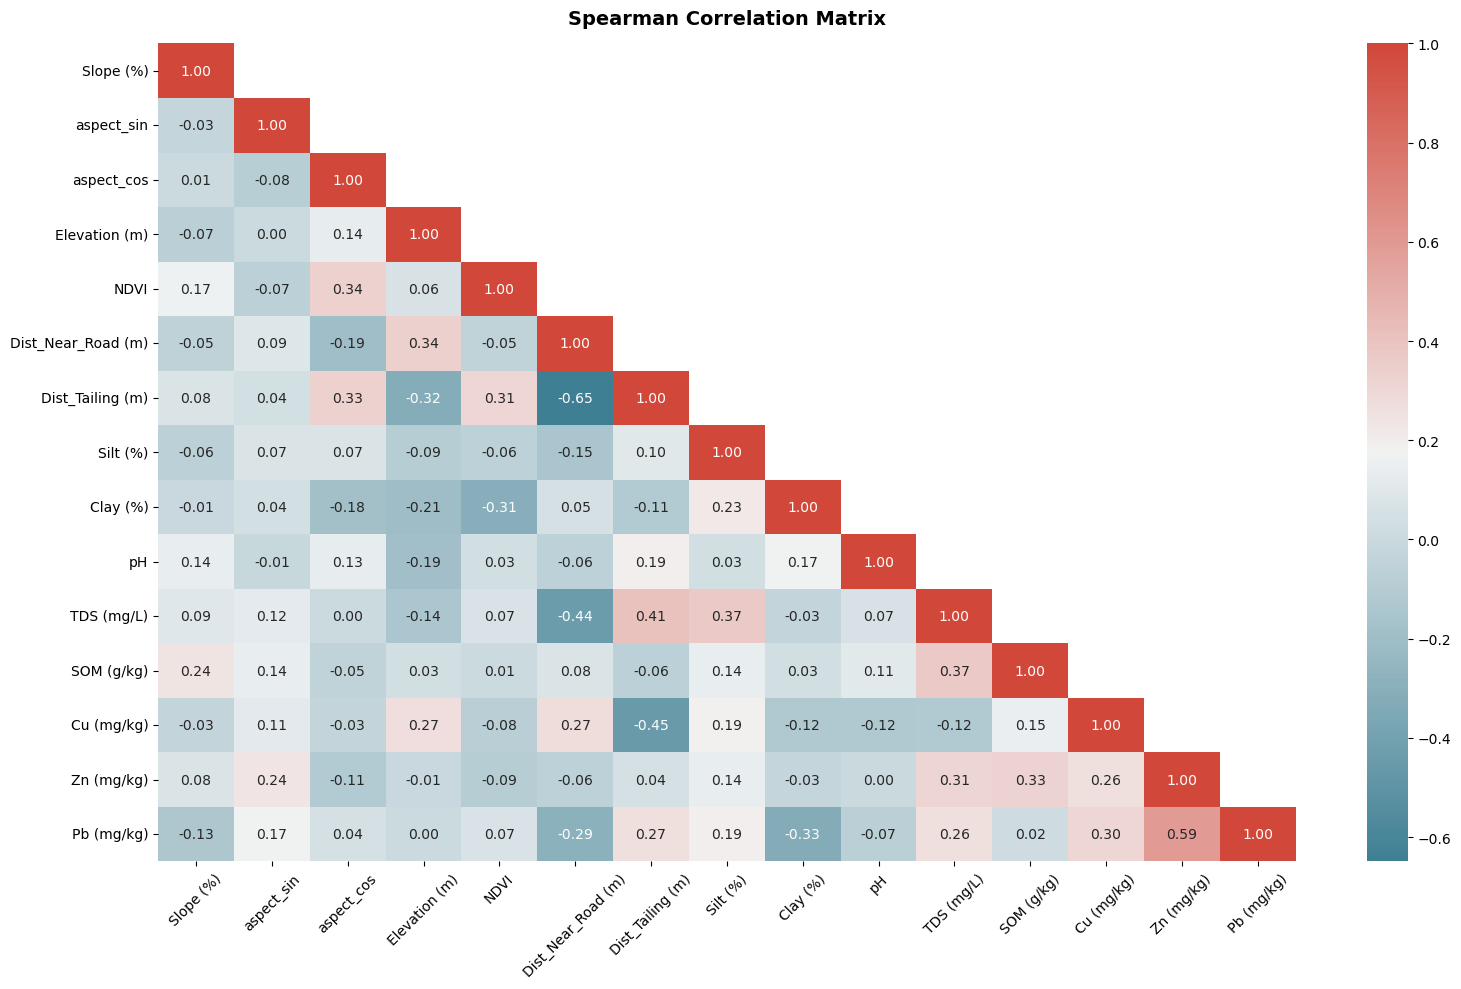

In [5]:
non_redundant_df = df.drop(['Longitude', 
                           'Latitude',
                           'Dist_Main_Road  (m)',
                           'Sand (%)',
                           'EC (µs/cm)'], axis=1).copy()
spearman_corr = spearman_correlation_analysis(non_redundant_df,
                                             output_filename="spearman_corr.csv",
                                             save=True,
                                             plot_filename="spearman_matrix.png",
                                             plot=True)

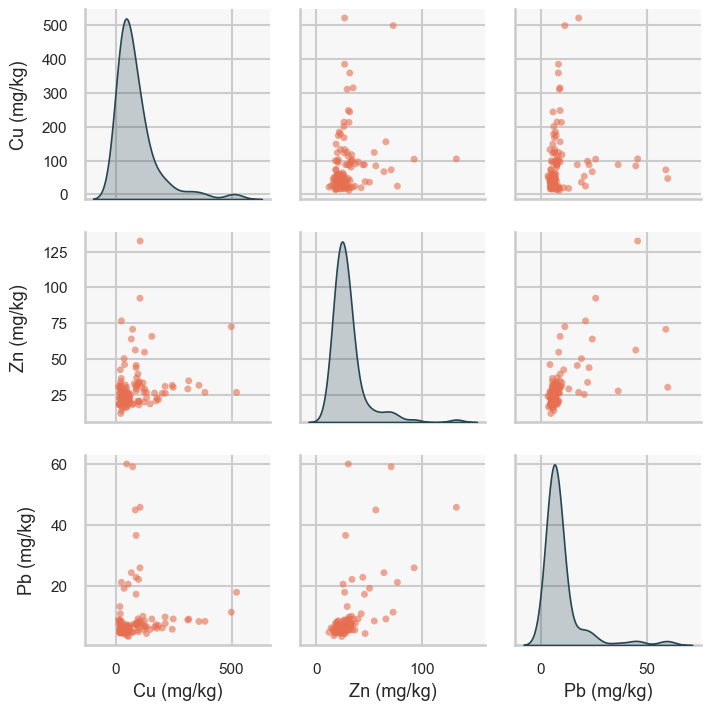

In [6]:
# Set style 
sns.set_theme(context="talk", style="whitegrid", font_scale=1.1)
sns.set_style({"axes.facecolor": "#f7f7f7"})

# Visualize from df, columns ["Cu (mg/kg)", "Zn (mg/kg)", "Pb (mg/kg)"]
cols_to_plot = ["Cu (mg/kg)", "Zn (mg/kg)", "Pb (mg/kg)"]  

# Subset and drop rows with missing values in the selected columns
pair_df = df[cols_to_plot].dropna()

# color palette
palette = sns.color_palette(["#264653", "#e76f51", "#2a9d8f"])

# Create the pairplot
g = sns.pairplot(
    pair_df,
    vars=cols_to_plot,
    corner=False,
    diag_kind="kde",
    plot_kws={
        "alpha": 0.6,
        "s": 25,
        "edgecolor": "none",
        "color": palette[1],
    },
    diag_kws={
        "fill": True,
        "color": palette[0],
        "linewidth": 1.2,
    },
)

# Refine axes labels and ticks
# x labels on the bottom row
for j, col_var in enumerate(cols_to_plot):
    ax = g.axes[-1, j]
    if ax is None:
        continue
    ax.set_xlabel(col_var.replace("_", " "), fontsize=13)
    ax.tick_params(axis="x", which="both", labelsize=11, labelbottom=True)

# y labels on the first column, including the TOP cell
for i, row_var in enumerate(cols_to_plot):
    ax = g.axes[i, 0]
    if ax is None:
        continue
    ax.set_ylabel(row_var.replace("_", " "), fontsize=13, labelpad=10)
    ax.tick_params(axis="y", which="both", labelsize=11, labelleft=True)


# Tight layout for clean spacing
plt.tight_layout()
g.savefig(f"{output_path}/target_pairwise_plot.png")
plt.show()

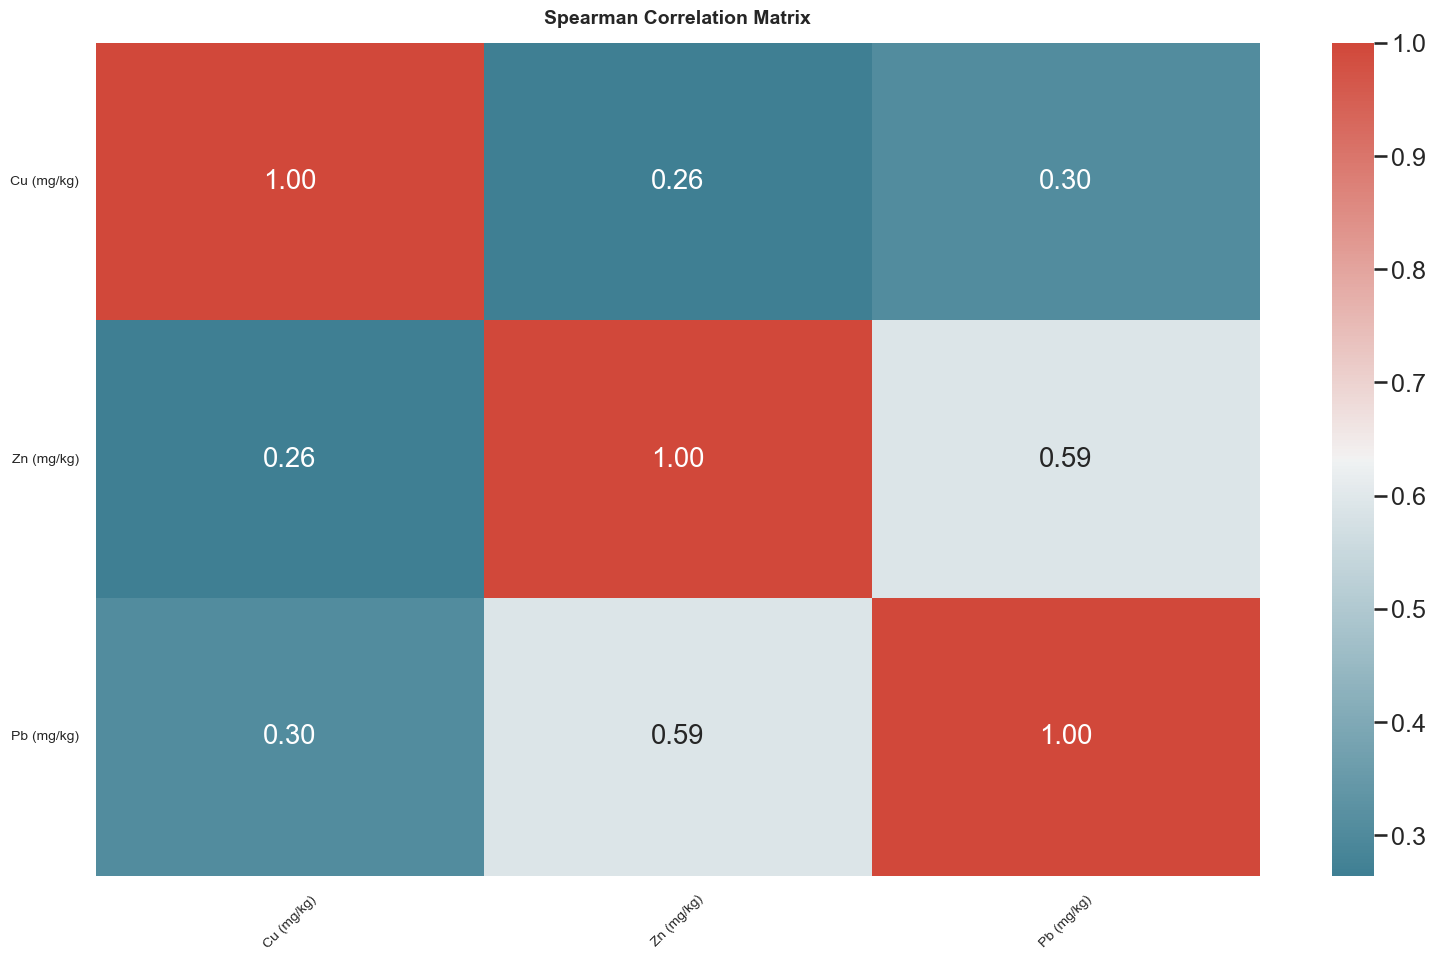

,Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
Cu (mg/kg),1.000000,0.264294,0.304687
Zn (mg/kg),0.264294,1.000000,0.589160
Pb (mg/kg),0.304687,0.589160,1.000000


In [7]:
target_df = continuous_df.drop(continuous_df.columns[:17], axis=1)

target_corr_matrix = spearman_correlation_analysis(target_df,
                                           output_filename="target_corr.csv",
                                           save=True,
                                            mask=False,
                                           plot_filename="Target_Corr_matrix.png",
                                           plot=True)

target_corr_matrix

In [8]:
df["Land Use"] = (df["Land Use"] == "residential").astype(int)
df = df.dropna()
cu_df = df.drop(["Sample_ID", "Zn (mg/kg)", "Pb (mg/kg)"], axis=1)
cu_df.head()

,Longitude,Latitude,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),Dist_Tailing (m),Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg)
0,16.654245,-23.791474,4.54993,-0.371390,0.928477,1554,0.0655,0,2473,1535,233,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980
1,16.654298,-23.791963,4.22451,0.800000,-0.600000,1557,0.0684,0,2507,1533,226,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081
2,16.654220,-23.792418,6.00415,0.633238,-0.773957,1555,0.0672,0,2529,1521,200,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819
3,16.654164,-23.792956,6.09267,0.832050,-0.554700,1551,0.0590,0,2559,1511,175,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907
4,16.653748,-23.792745,3.04634,0.554700,-0.832050,1554,0.0593,0,2511,1470,141,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931


In [9]:
df = pd.read_csv('../Data/BData.csv')

# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop(["Aspect (˚)", 'Sample_ID', 'Land Use'], axis=1, inplace=True)

df.head()

,Longitude,Latitude,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Dist_Main_Road (m),Dist_Near_Road (m),Dist_Tailing (m),Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,-0.371390,0.928477,1554,0.0655,2473,1535,233,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,0.800000,-0.600000,1557,0.0684,2507,1533,226,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,0.633238,-0.773957,1555,0.0672,2529,1521,200,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,0.832050,-0.554700,1551,0.0590,2559,1511,175,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,0.554700,-0.832050,1554,0.0593,2511,1470,141,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338


In [10]:
# Log transformation

features_log = ['Clay (%)',
                'SOM (g/kg)',
                'TDS (mg/L)',
                'NDVI',
               'Cu (mg/kg)',
               'Zn (mg/kg)',
               'Pb (mg/kg)']

for feature in features_log:
    df[feature] = np.log10(df[feature])

df.head()

,Longitude,Latitude,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Dist_Main_Road (m),Dist_Near_Road (m),Dist_Tailing (m),Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,-0.371390,0.928477,1554,-1.183759,2473,1535,233,91.2,7.6,0.079181,7.3,100.0,1.698970,0.193125,2.394417,1.480151,0.960138
1,16.654298,-23.791963,4.22451,0.800000,-0.600000,1557,-1.164944,2507,1533,226,87.9,10.4,0.204120,7.9,137.0,1.832509,0.217484,2.555192,1.499495,0.918135
2,16.654220,-23.792418,6.00415,0.633238,-0.773957,1555,-1.172631,2529,1521,200,91.8,7.0,0.113943,7.1,109.0,1.736397,0.418301,2.387068,1.498683,0.759592
3,16.654164,-23.792956,6.09267,0.832050,-0.554700,1551,-1.229148,2559,1511,175,89.7,8.8,0.176091,7.5,90.0,1.648360,0.352183,2.498182,1.540417,0.957655
4,16.653748,-23.792745,3.04634,0.554700,-0.832050,1554,-1.226945,2511,1470,141,86.4,12.0,0.204120,8.0,119.0,1.774517,0.326336,2.585383,1.425811,0.921062


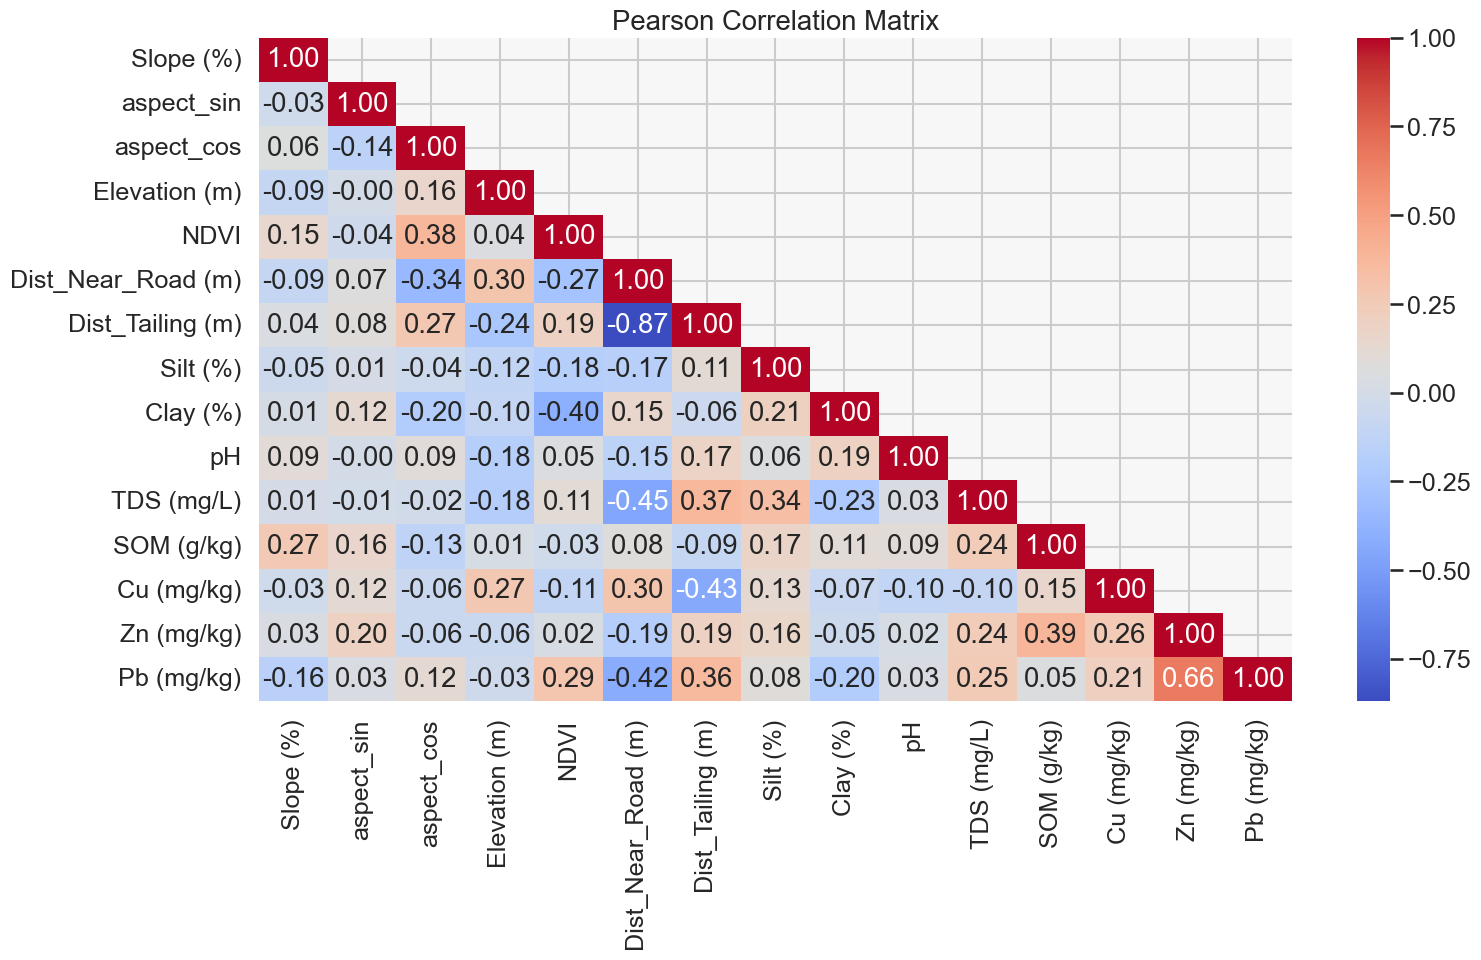

,Slope (%),aspect_sin,aspect_cos,Elevation (m),NDVI,Dist_Near_Road (m),Dist_Tailing (m),Silt (%),Clay (%),pH,TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
Slope (%),1.000000,-0.027528,0.060870,-0.091855,0.145297,-0.091586,0.039305,-0.049427,0.008228,0.094328,0.005345,0.268290,-0.029426,0.031227,-0.161107
aspect_sin,-0.027528,1.000000,-0.141131,-0.002102,-0.035490,0.065198,0.081383,0.005355,0.124104,-0.004672,-0.010061,0.156375,0.121315,0.197874,0.031522
aspect_cos,0.060870,-0.141131,1.000000,0.159668,0.383814,-0.343993,0.273638,-0.040766,-0.202646,0.092917,-0.022017,-0.130947,-0.063759,-0.063453,0.118898
Elevation (m),-0.091855,-0.002102,0.159668,1.000000,0.043174,0.297233,-0.244041,-0.115790,-0.102724,-0.182982,-0.184905,0.014547,0.273920,-0.062862,-0.032890
NDVI,0.145297,-0.035490,0.383814,0.043174,1.000000,-0.272121,0.190007,-0.181162,-0.402560,0.045138,0.106620,-0.029424,-0.114838,0.024906,0.286260
Dist_Near_Road (m),-0.091586,0.065198,-0.343993,0.297233,-0.272121,1.000000,-0.870002,-0.173596,0.149720,-0.146475,-0.454577,0.078393,0.297104,-0.186171,-0.418755
Dist_Tailing (m),0.039305,0.081383,0.273638,-0.244041,0.190007,-0.870002,1.000000,0.112329,-0.058193,0.174996,0.373889,-0.094008,-0.431890,0.194707,0.358108
Silt (%),-0.049427,0.005355,-0.040766,-0.115790,-0.181162,-0.173596,0.112329,1.000000,0.209771,0.056809,0.337539,0.173157,0.130137,0.164736,0.080177
Clay (%),0.008228,0.124104,-0.202646,-0.102724,-0.402560,0.149720,-0.058193,0.209771,1.000000,0.194804,-0.233831,0.106042,-0.071598,-0.046780,-0.203922
pH,0.094328,-0.004672,0.092917,-0.182982,0.045138,-0.146475,0.174996,0.056809,0.194804,1.000000,0.033283,0.094290,-0.104196,0.018995,0.031878


In [11]:
non_redundant_df = df.drop(['Longitude', 
                           'Latitude',
                           'Dist_Main_Road  (m)',
                           'Sand (%)',
                           'EC (µs/cm)'], axis=1).copy()

log_pearson_matrix = pearson_correlation_analysis(non_redundant_df, 
                            output_filename='pearson_log.csv',
                            save=True,
                            plot_filename='log_pearson.png',
                            plot=True)

log_pearson_matrix